In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\kadit\ML-Journey\datasets\wine_data.csv", header=None, usecols=[0, 1, 2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [4]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


C:\Users\kadit\AppData\Local\Temp\ipykernel_16184\2834799955.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Alcohol'], shade=True)


Text(0.5, 1.0, 'Alcohol Distribution')

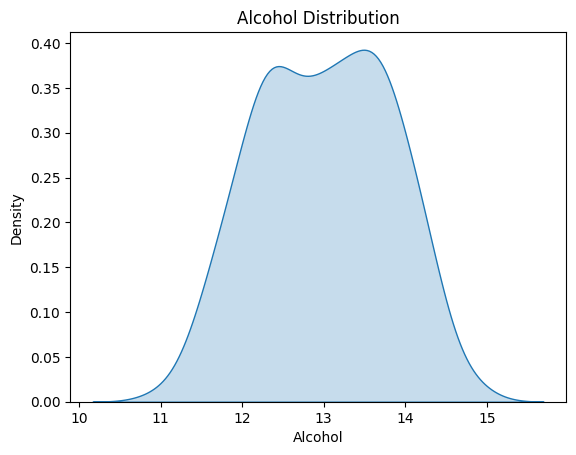

In [5]:
sns.kdeplot(df['Alcohol'], shade=True)
plt.title('Alcohol Distribution')

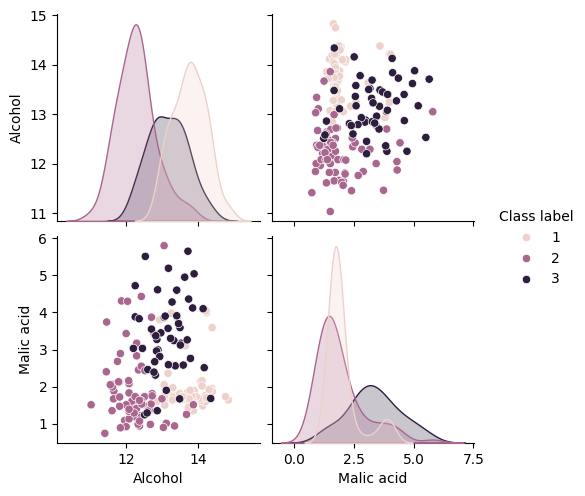

In [6]:
sns.pairplot(df, hue='Class label')
plt.show()

C:\Users\kadit\AppData\Local\Temp\ipykernel_16184\3429979485.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Malic acid'], shade=True)


Text(0.5, 1.0, 'Malic acid Distribution')

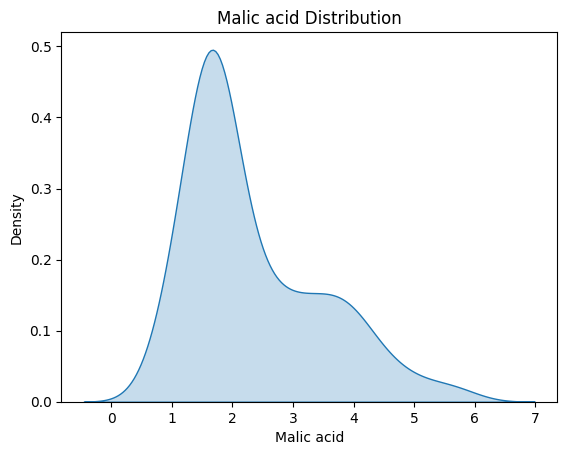

In [7]:
sns.kdeplot(df['Malic acid'], shade=True)
plt.title('Malic acid Distribution')

In [8]:
# As mentioned before performing any type of scaling (standardization or normaliztion) we need to first perform train-test split.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [12]:
# Before scaling data:

np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [ ]:
# After scaling data:

np.round(X_train_scaled.describe(), 1)

# As we can observe, min value = 0 and max value = 1

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


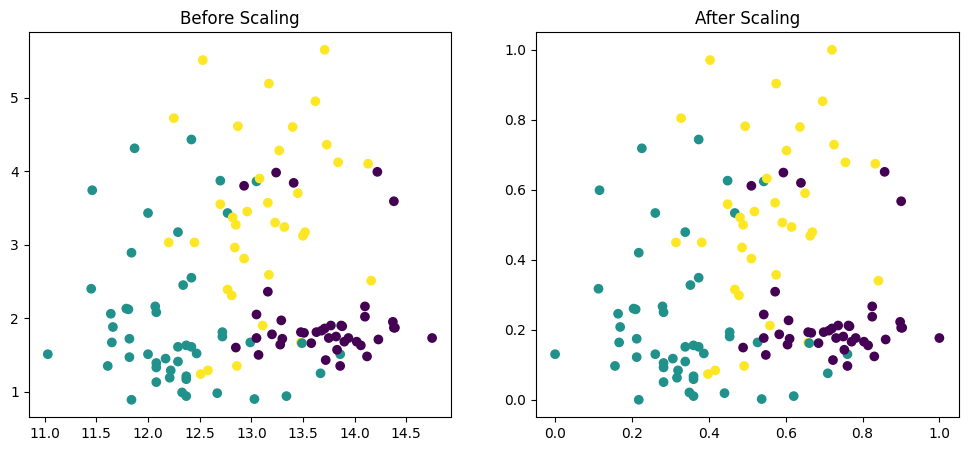

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train, cmap='viridis')
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train, cmap='viridis')
ax2.set_title('After Scaling')
plt.show()

# As we can see, after Min-Max scaling, the data is squished between 0 and 1, which is the expected behavior of Min-Max scaling.